In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip


# 1. Импорт библиотек и проверка каталога с данными

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


# 2. загрузка данных

In [3]:
DATA = '/kaggle/input/competitions/flight-delays-fall-2018'
train = pd.read_csv(f'{DATA}/flight_delays_train.csv.zip')
test = pd.read_csv(f'{DATA}/flight_delays_test.csv.zip')
print('train:', train.shape, '| test:', test.shape)
train.head()

train: (100000, 9) | test: (100000, 8)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


# 3. редобработка и признаки. Оформление подготовки данных.

In [4]:
def transform(df):
    df = df.copy()
    # Поля 'c-8', 'c-21', 'c-7' -> целые числа
    for col in ['Month', 'DayofMonth', 'DayOfWeek']:
        df[col] = df[col].str.replace('c-', '', regex=False).astype(int)
    # Час вылета из DepTime (hhmm)
    df['DepHour'] = (df['DepTime'] // 100).clip(0, 23).astype(int)
    df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)
    return df
train_fe = transform(train)
test_fe = transform(test)
# Целевая переменная 'Y'/'N' -> 1/0
train_fe['target'] = (train_fe['dep_delayed_15min'] == 'Y').astype(int)
# Сохранение обработанного датасета (load -> transform -> save)
os.makedirs('/kaggle/working', exist_ok=True)
train_fe.to_parquet('/kaggle/working/train_processed.parquet', index=False)
print('Сохранено:', train_fe.shape)


Сохранено: (100000, 12)


In [5]:
train_fe.head()

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min,DepHour,IsWeekend,target
0,8,21,7,1934,AA,ATL,DFW,732,N,19,1,0
1,4,20,3,1548,US,PIT,MCO,834,N,15,0,0
2,9,2,5,1422,XE,RDU,CLE,416,N,14,0,0
3,11,25,6,1015,OO,DEN,MEM,872,N,10,1,0
4,10,7,6,1828,WN,MDW,OMA,423,Y,18,1,1


# 4. Разведочный анализ данных.

Доля задержанных рейсов: 0.19


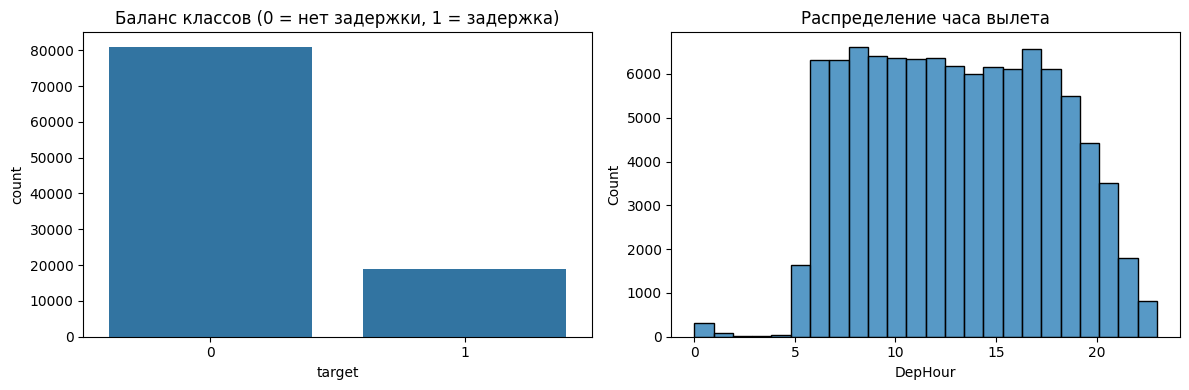

In [6]:
print('Доля задержанных рейсов:', round(train_fe['target'].mean(), 3))\

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='target', data=train_fe, ax=axes[0])
axes[0].set_title('Баланс классов (0 = нет задержки, 1 = задержка)')
sns.histplot(train_fe['DepHour'], bins=24, ax=axes[1])
axes[1].set_title('Распределение часа вылета')
plt.tight_layout(); plt.show()


# 5. Модель и валидация.

In [7]:
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest']

# One-Hot кодирование (общий набор столбцов для train и test)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
ohe.fit(pd.concat([train_fe[CAT_FEATURES], test_fe[CAT_FEATURES]]))

X = hstack([train_fe[NUM_FEATURES].values, ohe.transform(train_fe[CAT_FEATURES])]).tocsr()
y = train_fe['target'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_tr, y_tr)

val_pred = model.predict_proba(X_val)[:, 1]
print('Validation ROC AUC:', round(roc_auc_score(y_val, val_pred), 4))


Validation ROC AUC: 0.7005


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 6. Прогноз и отправка решения.

In [8]:
X_test = hstack([test_fe[NUM_FEATURES].values, ohe.transform(test_fe[CAT_FEATURES])]).tocsr()
test_pred = model.predict_proba(X_test)[:, 1]

submission = pd.read_csv(f'{DATA}/sample_submission.csv.zip')
submission['dep_delayed_15min'] = test_pred
submission.to_csv('/kaggle/working/submission.csv', index=False)
submission.head()

,id,dep_delayed_15min
0,0,0.092894
1,1,0.103020
2,2,0.089478
3,3,0.234036
4,4,0.241246


# 7.1. Максимизация метрики (улучшение модели). Модель XGBoost.

In [9]:
import xgboost as xgb

In [10]:
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest']

# One-Hot кодирование (общий набор столбцов для train и test)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
ohe.fit(pd.concat([train_fe[CAT_FEATURES], test_fe[CAT_FEATURES]]))

X = hstack([train_fe[NUM_FEATURES].values, ohe.transform(train_fe[CAT_FEATURES])]).tocsr()
y = train_fe['target'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
model.fit(X_tr, y_tr)

val_pred = model.predict_proba(X_val)[:, 1]
print('Validation ROC AUC:', round(roc_auc_score(y_val, val_pred), 4))


Validation ROC AUC: 0.7426


# 7.2. Максимизация метрики (улучшение модели). Модель LightGBM.

In [11]:
import lightgbm as lgb

In [12]:
NUM_FEATURES = ['Month', 'DayofMonth', 'DayOfWeek', 'DepHour', 'Distance', 'IsWeekend']
CAT_FEATURES = ['UniqueCarrier', 'Origin', 'Dest']

# One-Hot кодирование (общий набор столбцов для train и test)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
ohe.fit(pd.concat([train_fe[CAT_FEATURES], test_fe[CAT_FEATURES]]))

X = hstack([train_fe[NUM_FEATURES].values, ohe.transform(train_fe[CAT_FEATURES])]).tocsr()
y = train_fe['target'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_tr, y_tr)

val_pred = model.predict_proba(X_val)[:, 1]
print('Validation ROC AUC:', round(roc_auc_score(y_val, val_pred), 4))

Validation ROC AUC: 0.7426


In [13]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score
import time

# === ПОДГОТОВКА ДАННЫХ ===

# === ОПРЕДЕЛЕНИЕ СЕТКИ ГИПЕРПАРАМЕТРОВ ===
param_grid = {
    'n_estimators': [100, 200, 300],           # количество деревьев
    'max_depth': [4, 6, 8, 10],                # глубина деревьев
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # скорость обучения
    'subsample': [0.7, 0.8, 0.9],              # доля выборки для каждого дерева
    'colsample_bytree': [0.7, 0.8, 0.9],       # доля признаков для каждого дерева
    'min_child_weight': [1, 3, 5]              # минимальный вес в листе
}

# Базовый классификатор
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1
)

# === СТРАТИФИЦИРОВАННАЯ КРОСС-ВАЛИДАЦИЯ ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === GRID SEARCH ===
print("Начинаем GridSearchCV...")
print(f"Всего комбинаций: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['subsample']) * len(param_grid['colsample_bytree']) * len(param_grid['min_child_weight'])}")
print("Это может занять 10-30 минут...")

start_time = time.time()

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,              # используем все ядра
    verbose=2,              # выводим прогресс
    return_train_score=True
)

grid_search.fit(X_tr, y_tr)

end_time = time.time()
print(f"\nGridSearch завершен за {round((end_time - start_time)/60, 2)} минут")

# === РЕЗУЛЬТАТЫ ===
print("\n" + "="*50)
print("ЛУЧШИЕ ПАРАМЕТРЫ:")
print("="*50)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nЛучший ROC AUC (CV): {round(grid_search.best_score_, 4)}")

# === ОЦЕНКА НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ ===
best_model = grid_search.best_estimator_
val_pred = best_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, val_pred)
print(f"ROC AUC на валидационной выборке: {round(val_auc, 4)}")

# === СОХРАНЕНИЕ МОДЕЛИ ===
import joblib
joblib.dump(best_model, '/kaggle/working/xgboost_best_model.pkl')
print("\nМодель сохранена в /kaggle/working/xgboost_best_model.pkl")

Начинаем GridSearchCV...
Всего комбинаций: 1296
Это может занять 10-30 минут...
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.7; total time=   2.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.7, learning_rate=0.0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:20:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:20:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   1.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.9; total time=   1.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.7; total time=   2.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=200, subsample=0.9; total time=   2.5s
[CV] END colsample_bytree=0.7, learning_rate=0.0

...


[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=1, n_estimators=200, subsample=0.7; total time=   3.1s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   3.1s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=1, n_estimators=200, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.7; total time=   4.6s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.8; total time=   4.5s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.9; total time=   4.2s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.9; total time=   4.2s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:32:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:32:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:32:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:32:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=100, subsample=0.9; total time=   1.6s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=100, subsample=0.9; total time=   1.6s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=200, subsample=0.7; total time=   3.0s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=200, subsample=0.8; total time=   3.0s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   3.1s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=300, subsample=0.7; total time=   4.4s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:33:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:33:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:33:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:33:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


GridSearch завершен за 140.31 минут

ЛУЧШИЕ ПАРАМЕТРЫ:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 10
  min_child_weight: 1
  n_estimators: 300
  subsample: 0.8

Лучший ROC AUC (CV): 0.7427
ROC AUC на валидационной выборке: 0.7502

Модель сохранена в /kaggle/working/xgboost_best_model.pkl
